In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
from hydra.utils import instantiate
from hydra import initialize, compose
import hydra
import wandb

from model.modelCreator import ModelCreator
from omegaconf import OmegaConf
from scripts.run_transfusion import setup_model
from data.dataManager import DataManagerLayers
import copy
import gc

/usr/local/lib/python3.12/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
[18:15:10.198] INFO   CaloQuVAE                                         Loading configuration.
[18:15:11.508] INFO   numexpr.utils                                     Note: detected 96 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
[18:15:11.509] INFO   numexpr.utils                                     Note: NumExpr detected 96 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
[18:15:11.510] INFO   numexpr.utils                                     NumExpr defaulting to 16 threads.


In [2]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None, config_path="config")
cfg=compose(config_name="tfusion_config.yaml")
wandb.init(tags = [cfg.data.dataset_name], project=cfg.wandb.project, entity=cfg.wandb.entity, config=OmegaConf.to_container(cfg, resolve=True), mode='disabled')

In [3]:
new_model = False
if new_model:
    self = setup_model(cfg)
else:
    config = OmegaConf.load(cfg.config_path)
    config.gpu_list = cfg.gpu_list
    config.load_state = cfg.load_state
    self = setup_model(config)
    self._model_creator.load_state(config.run_path, self.device)


[18:15:15.147] INFO   data.dataManager                                  Loading ATLAS Layer dataset: AtlasCustom2
[18:15:18.928] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=399990, Val=49994
[18:15:18.930] INFO   data.dataManager                                  Loading feature statistics from /fast_scratch_1/caloqvae/lzhu/wandb/run-20260225_231755-ubgp0yf2/files/feature_stats.pt
[18:15:18.937] INFO   data.dataManager                                  Train: 399990 events, 98 batches
[18:15:18.938] INFO   data.dataManager                                  Val: 49994 events, 13 batches
[18:15:18.939] INFO   data.dataManager                                  Test: 50016 events, 13 batches
[18:15:18.940] INFO   model.modelCreator                                ::Creating Model
[18:15:19.130] INFO   scripts.run                                       Requesting GPUs. GPU list :[2]
[18:15:19.131] INFO   scripts.run                          

Loading weights for module =  net


In [ ]:
all_x = []
for (x, x0) in self.data_mgr.val_loader:
    all_x.append(x.cpu()[:, 1])

all_x = torch.cat(all_x, dim=0)
plt.hist(all_x.cpu().numpy().flatten(), bins=100, log=True)

In [ ]:
for epoch in range(1):
    self.fit_tfusion(epoch=epoch)

In [ ]:
save_config_path = self._save_model(name="test", override_path="/home/leozhu/CaloQuVAE/wandb-outputs")
save_config = OmegaConf.load(save_config_path)
self = setup_model(save_config)
self._model_creator.load_state_tfusion(save_config.run_path, device=self._device, opt=self.optimizer, sched=self.scheduler)

[18:18:17.918] INFO   data.dataManager                                  Loading ATLAS Layer dataset: AtlasCustom2
[18:18:21.142] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=399990, Val=49994
[18:18:21.143] INFO   data.dataManager                                  Loading feature statistics from /fast_scratch_1/caloqvae/lzhu/wandb/run-20260225_231755-ubgp0yf2/files/feature_stats.pt
[18:18:21.147] INFO   data.dataManager                                  Train: 399990 events, 782 batches
[18:18:21.148] INFO   data.dataManager                                  Val: 49994 events, 49 batches
[18:18:21.149] INFO   data.dataManager                                  Test: 50016 events, 49 batches
[18:18:21.417] INFO   engine.engine_transfusion                         Epoch: 0 [0/49 (0%)]	 Batch Loss: 48.9522
[18:18:21.739] INFO   engine.engine_transfusion                         Validation Loss: 46.2159


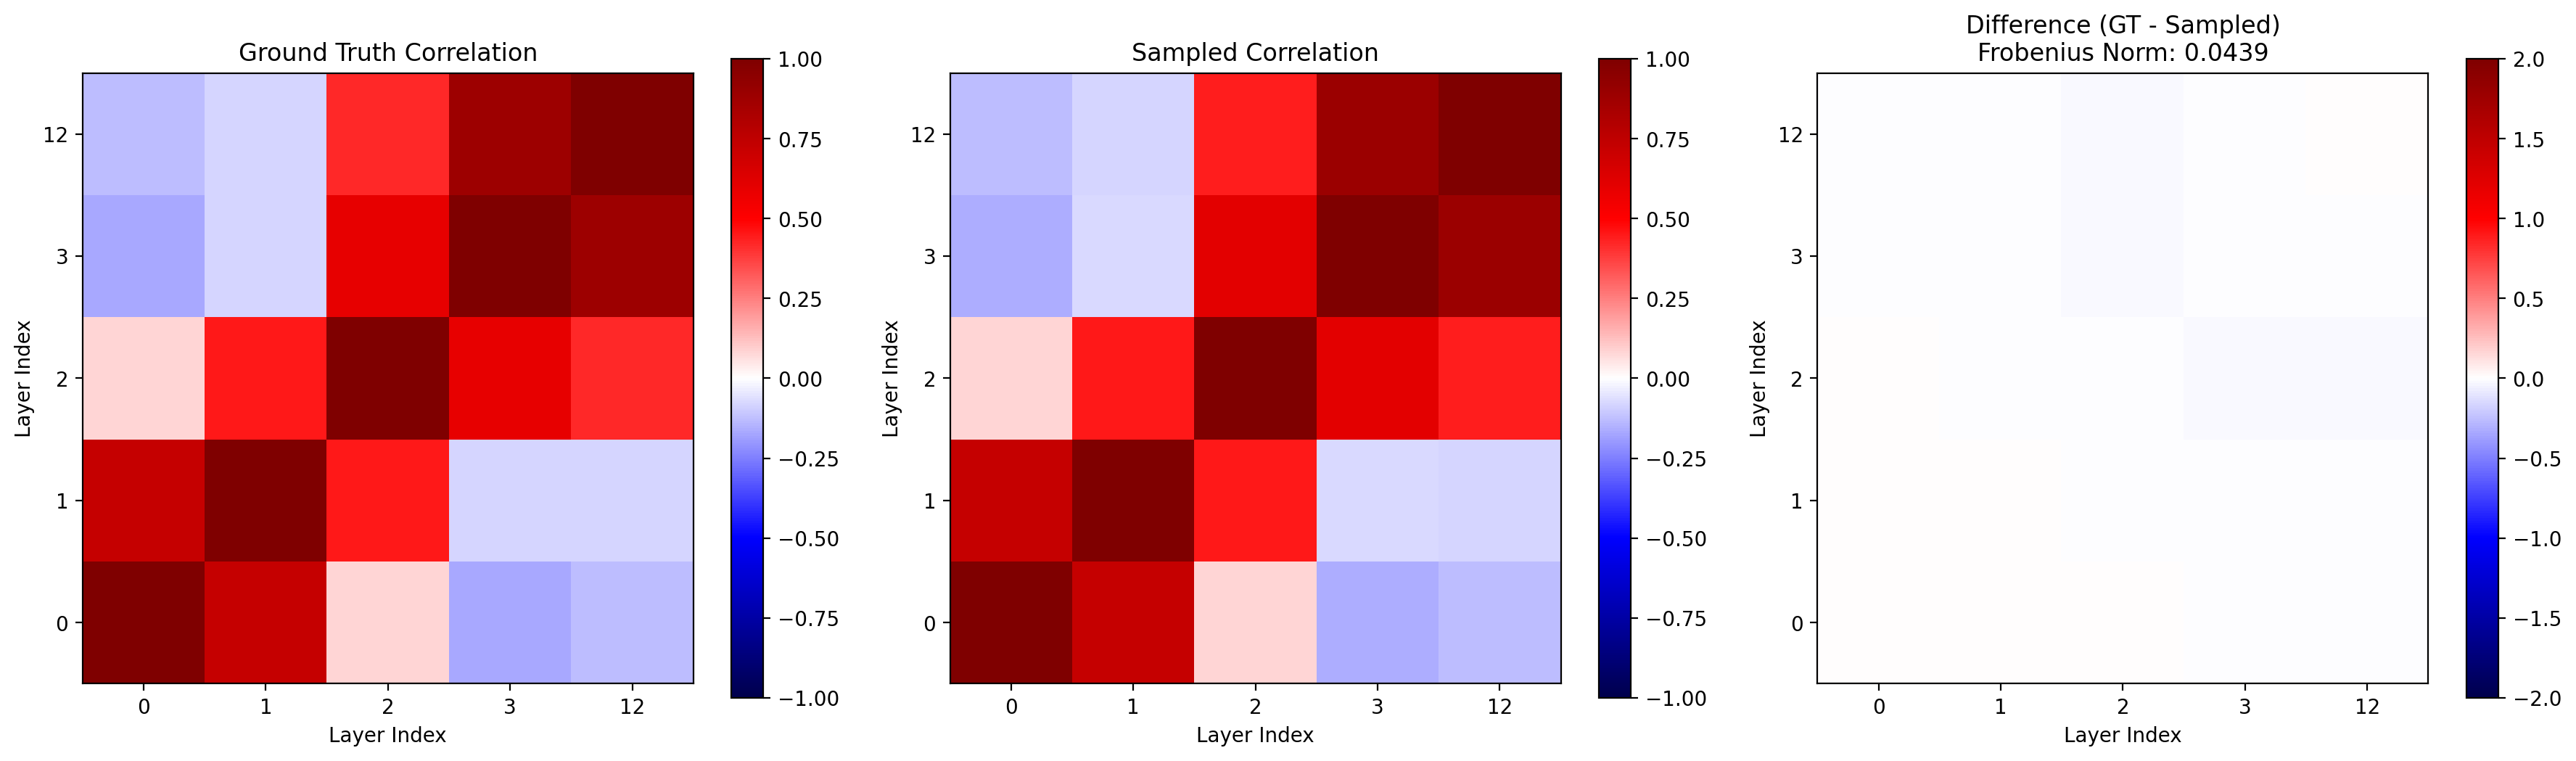

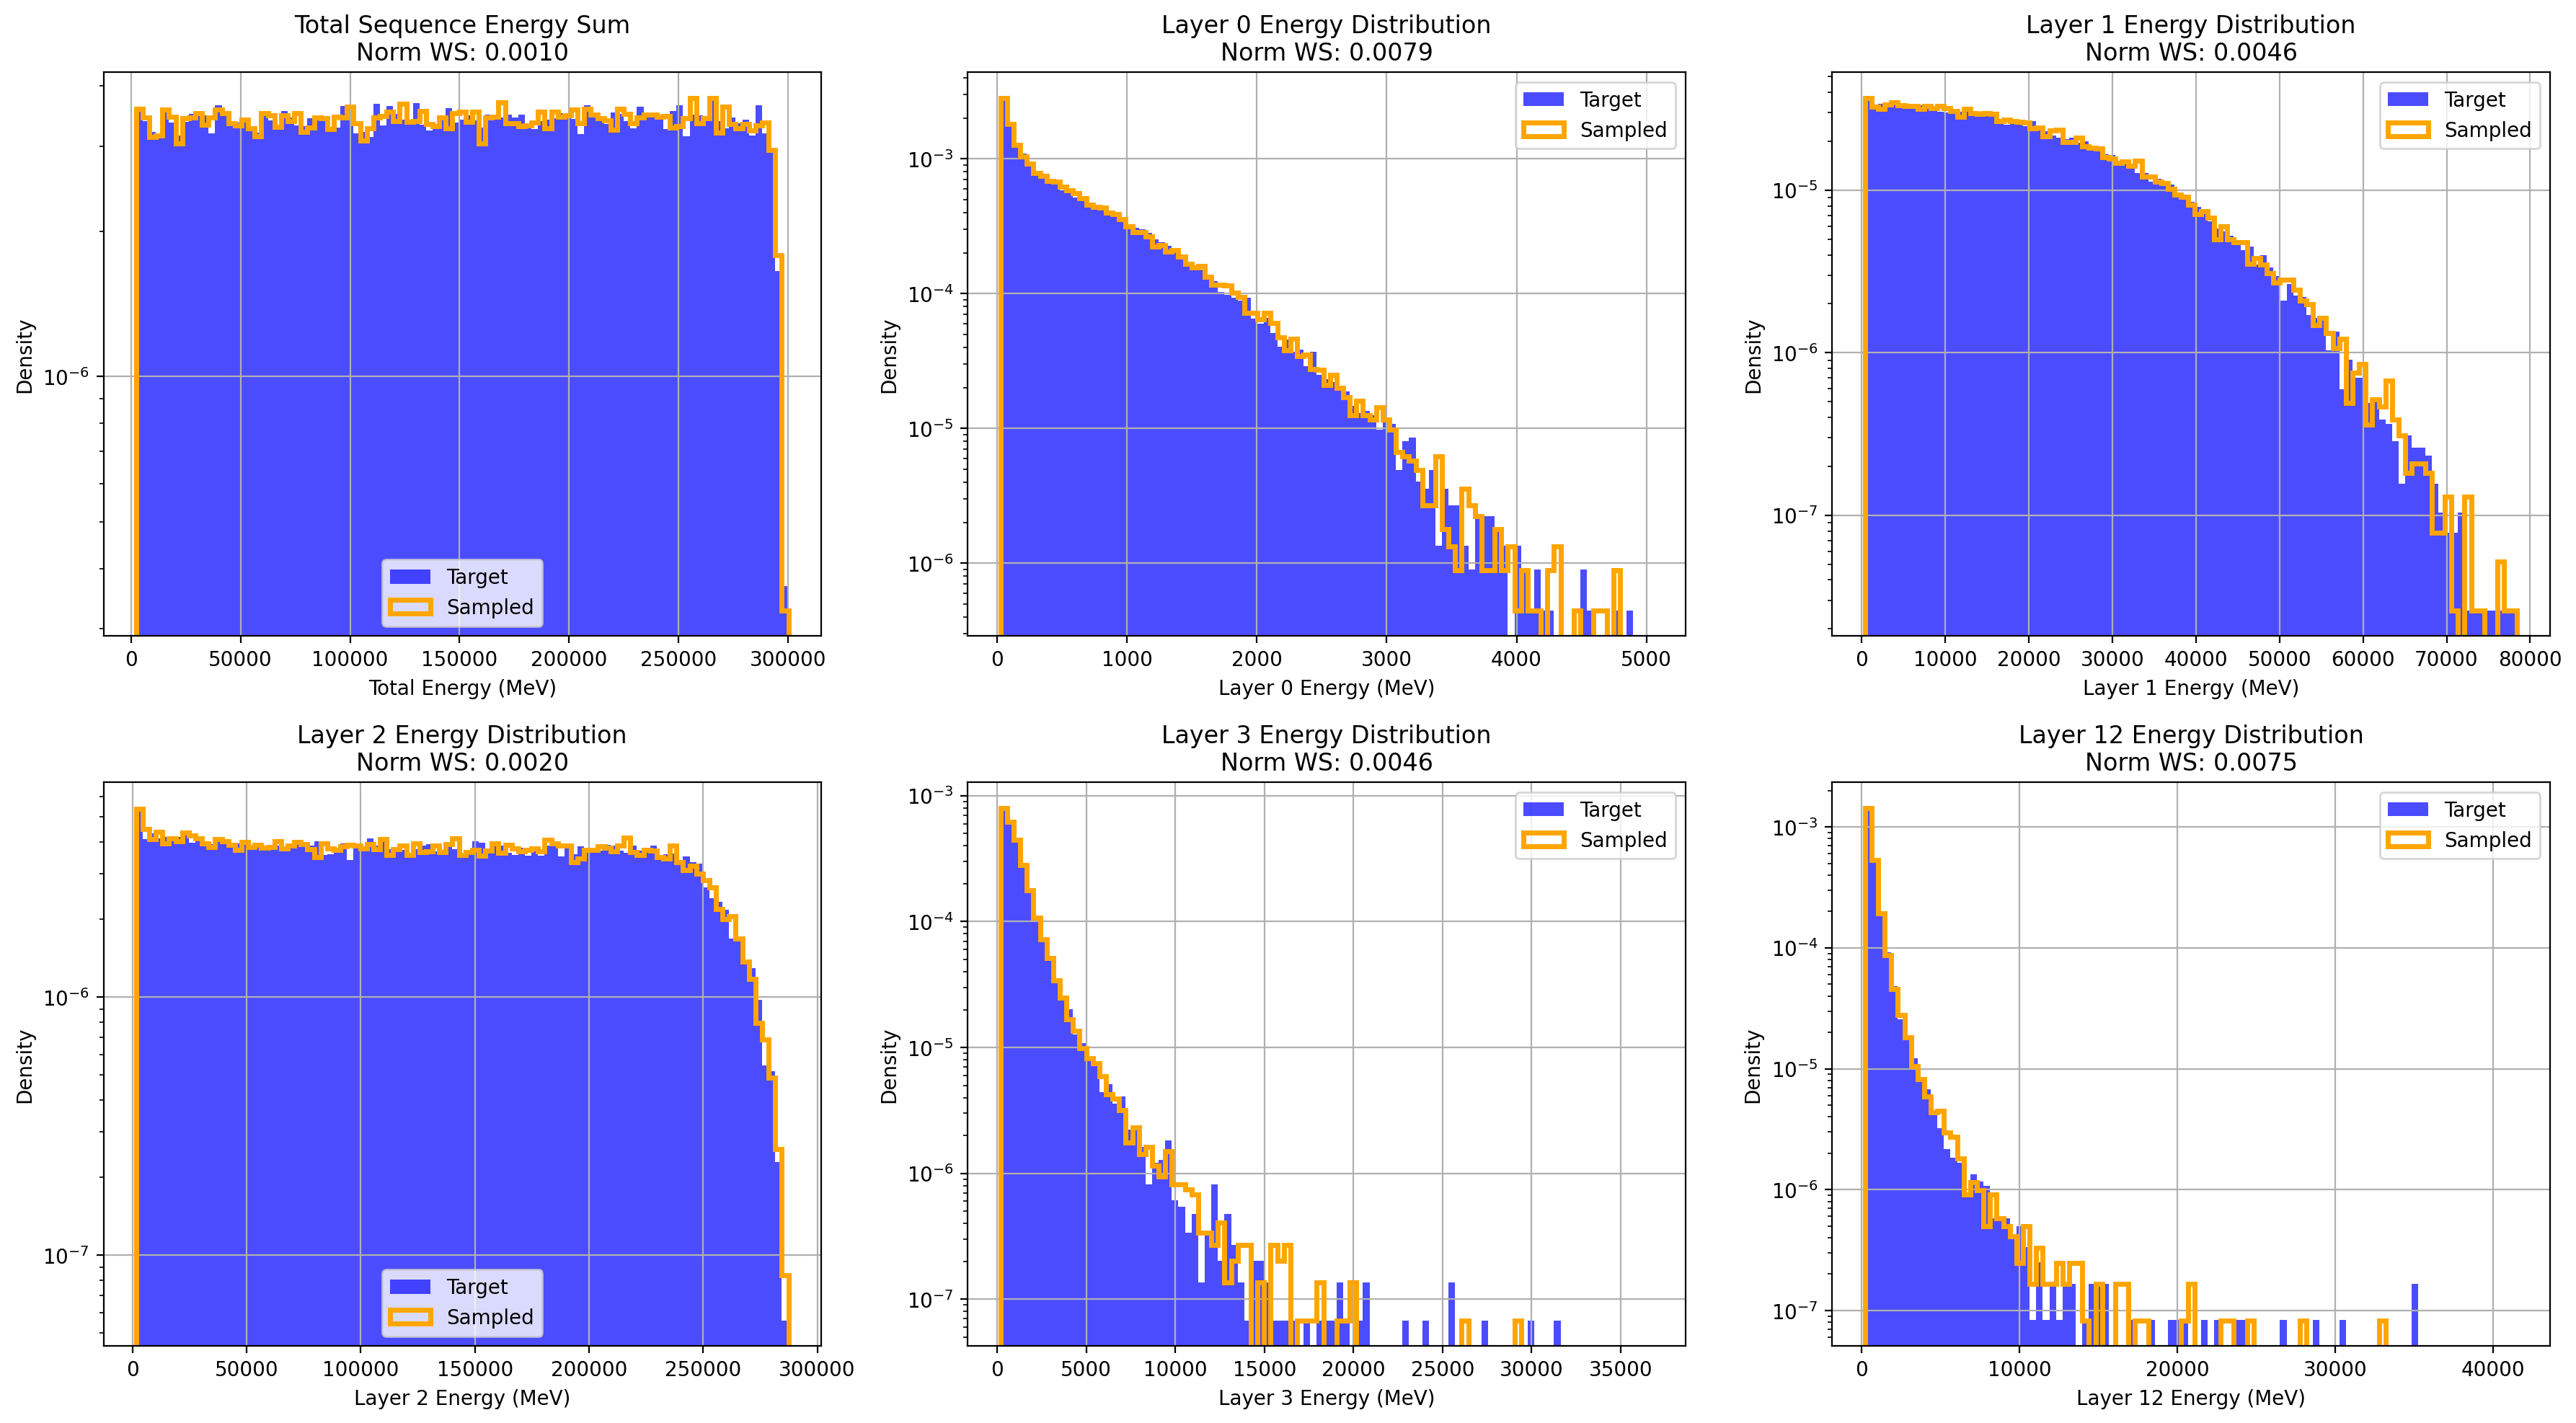

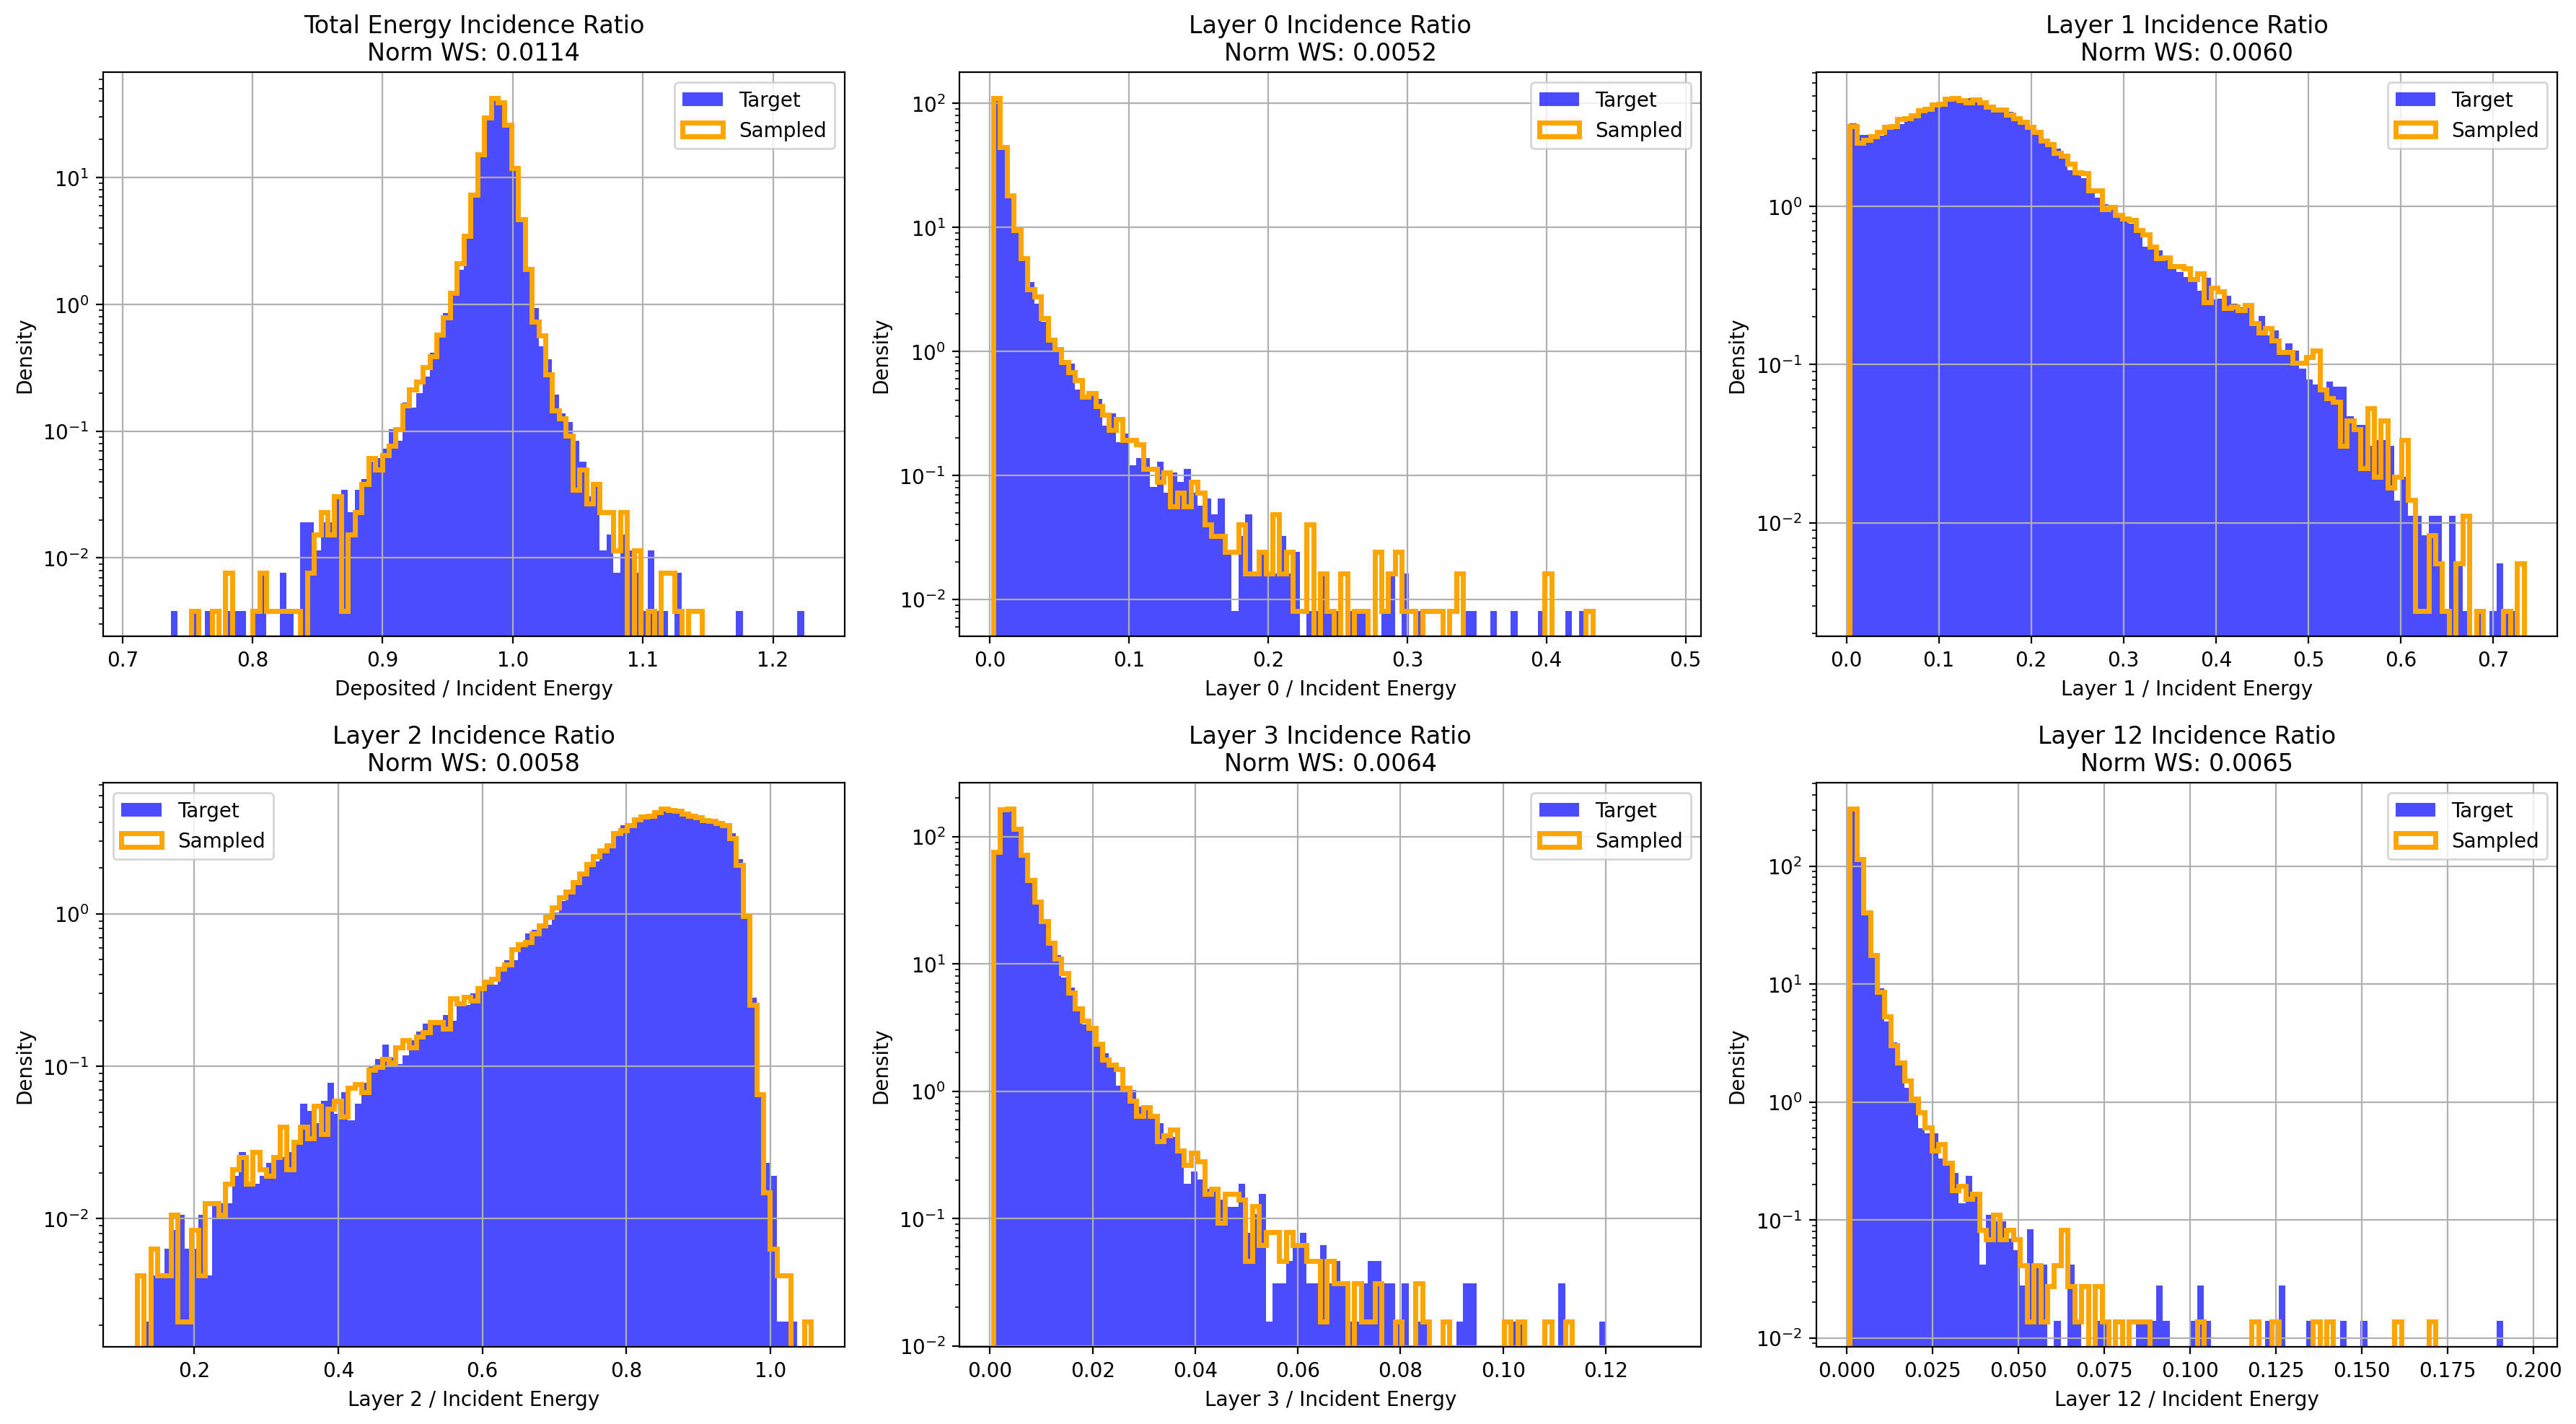

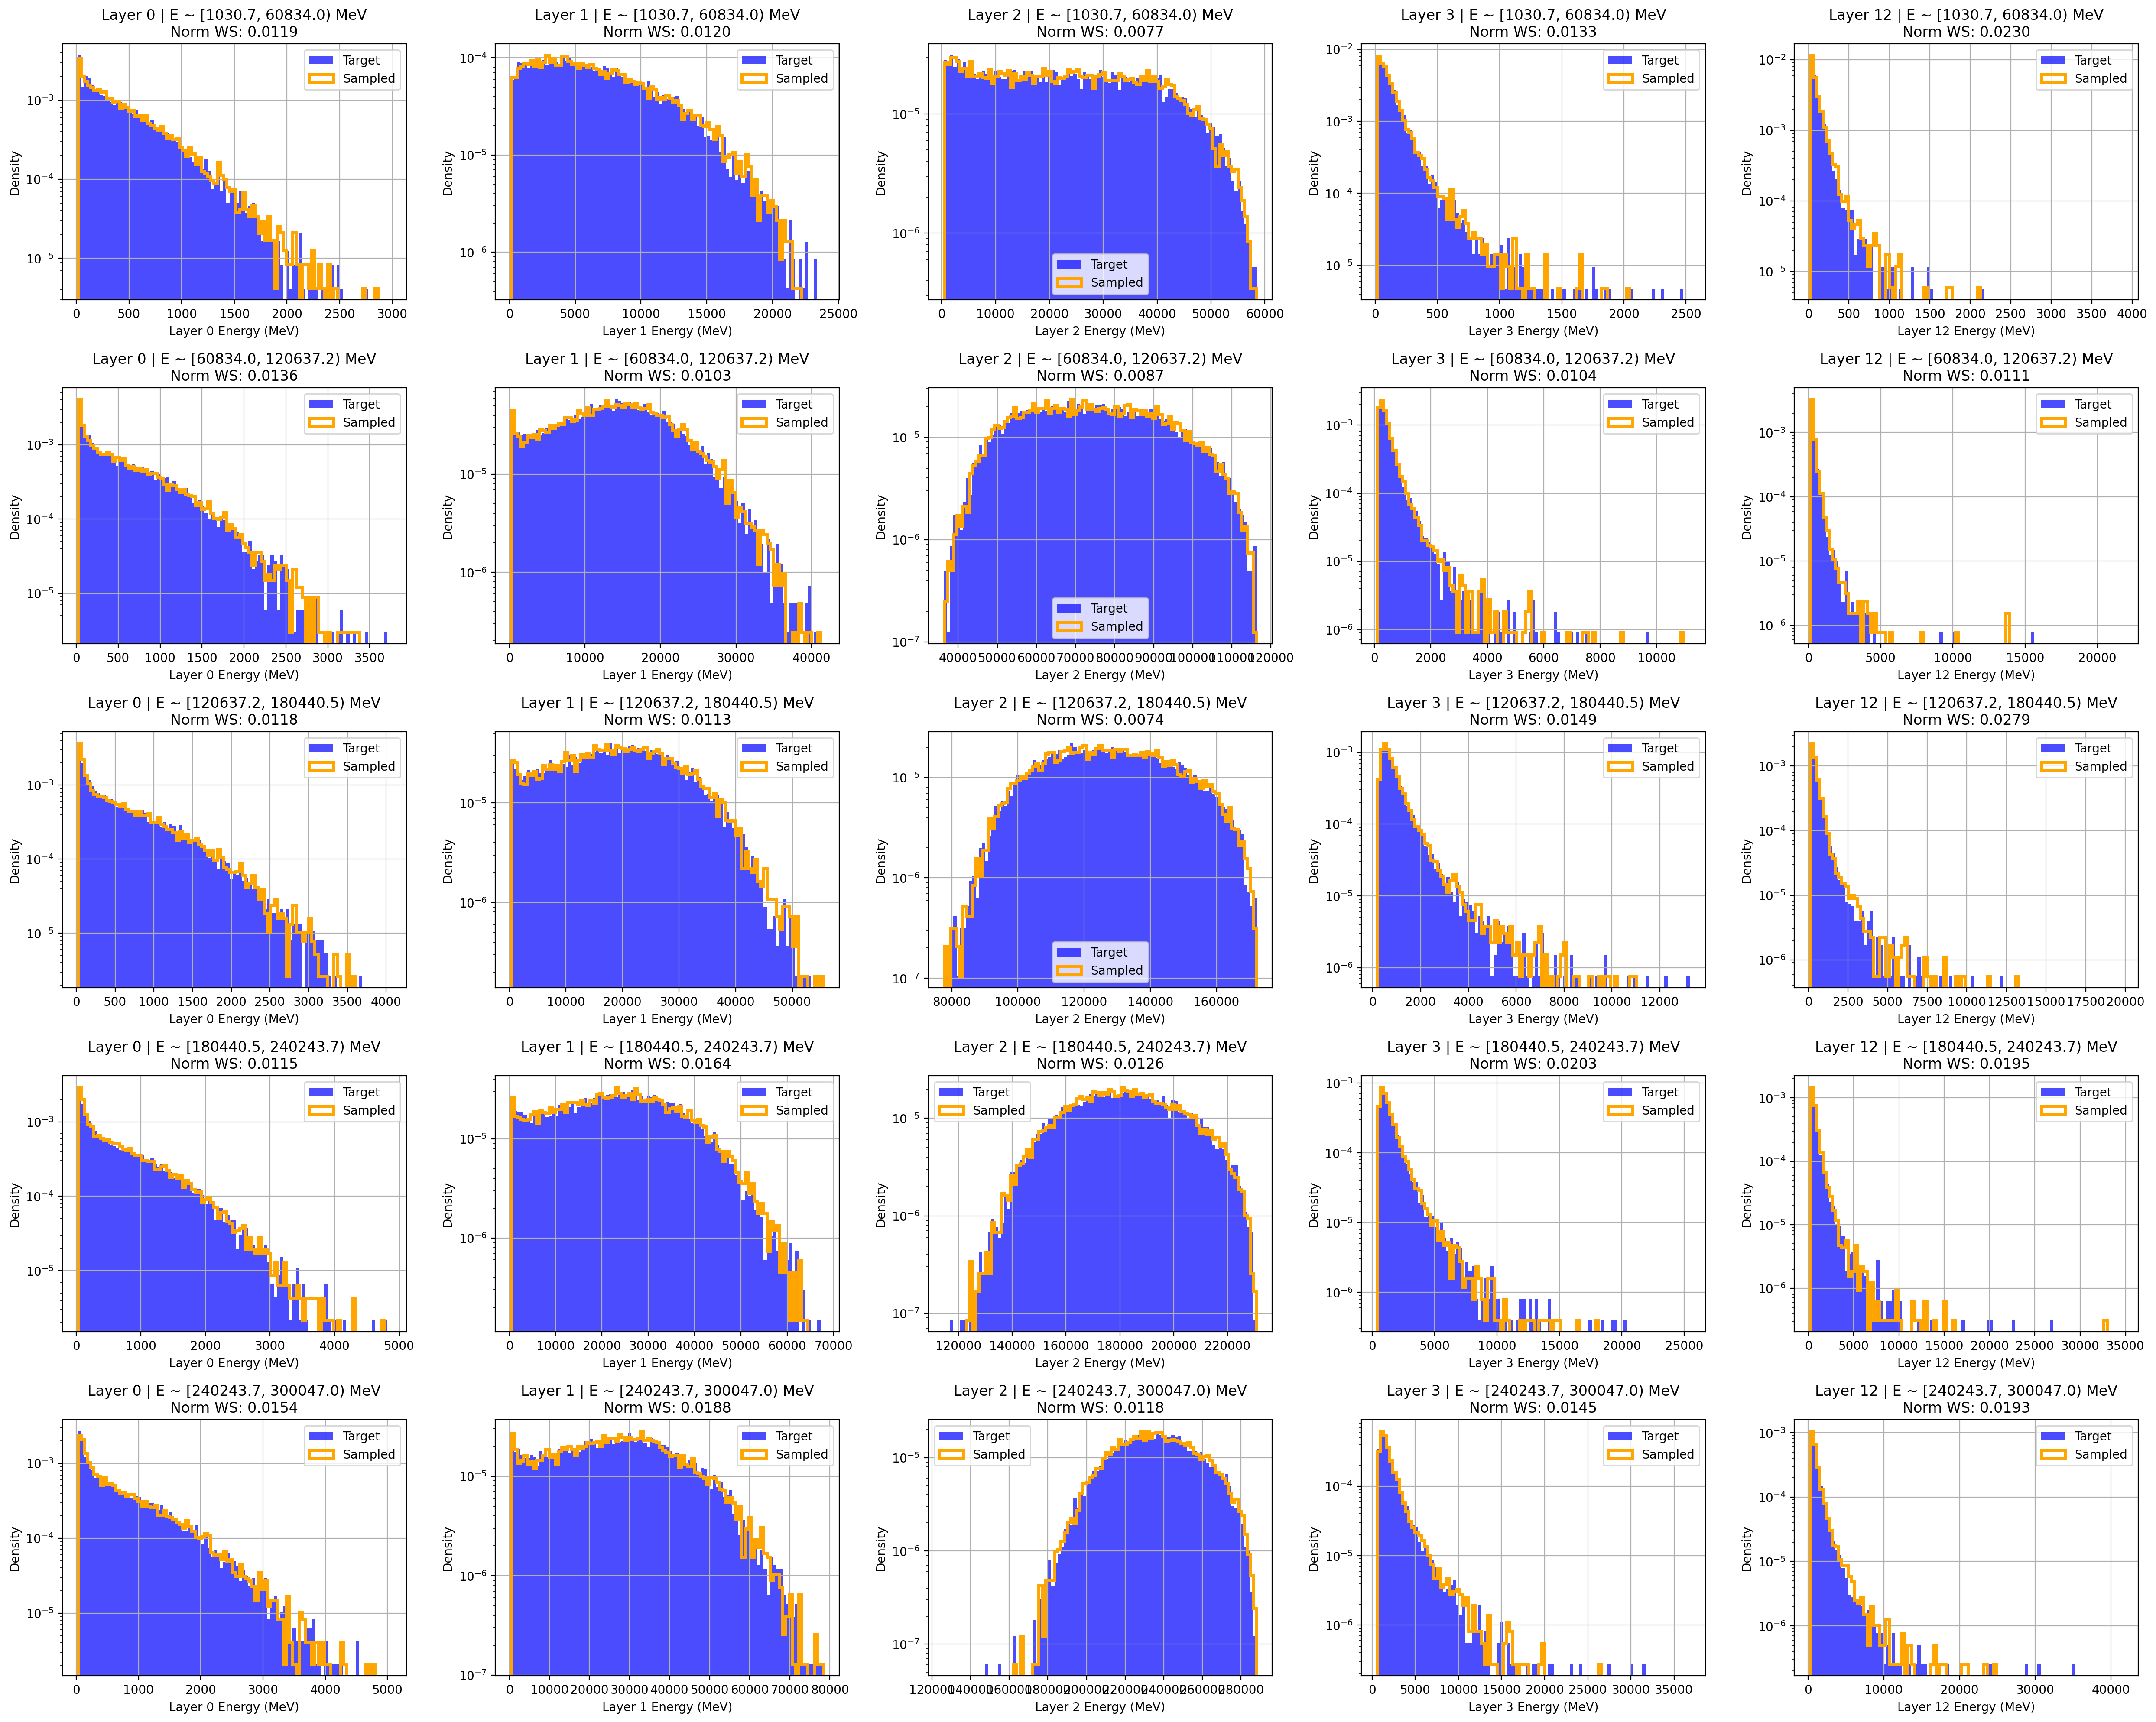

In [5]:
for validation_dataset in cfg.validation_datasets[:1]:
    val_cfg = copy.deepcopy(config)
    val_cfg.data = OmegaConf.load(f"config/data/{validation_dataset}.yaml")    
    val_data_manager = DataManagerLayers(val_cfg)
    self.evaluate_tfusion(val_data_manager.val_loader, epoch = 0, close_plots=False)


In [ ]:
# total parameters (trainable + frozen)
total = sum(p.numel() for p in self.model.parameters())  # [web:3]

# trainable parameters only
trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)  # [web:3]

print("Total params:", total)
print("Trainable params:", trainable)

print(sum(p.numel() for p in self.model.net.parameters()))


In [ ]:

def find_max_batch_size(model, baseline_batch_size=4096):
    """
    Finds the maximum inference batch size that fits in GPU memory.
    """
    model.eval()
    device = next(model.parameters()).device
    print(f"Testing on device: {device}")
    
    low = baseline_batch_size
    current_size = baseline_batch_size * 2
    high = None
    
    print(f"Phase 1: Finding upper bound starting from {baseline_batch_size}...")
    
    # Phase 1: Exponential Search
    while True:
        try:
            dummy_incidence = torch.randn(current_size, 1, 1, device=device)
            
            with torch.no_grad():
                _ = model.net(incidence_energy=dummy_incidence, rev=True)
                
            # If it passes, update our safe lower bound and double the size
            low = current_size
            print(f"✓ Batch size {current_size} fits. Doubling...")
            current_size *= 2
            
            # Clean up successful tensors before next iteration
            del dummy_incidence
            
        except torch.cuda.OutOfMemoryError:
            # We hit the ceiling
            high = current_size
            print(f"✗ OOM at batch size {high}. Ceiling found.")
            
            # Mandatory cleanup to release memory back to the GPU
            torch.cuda.empty_cache()
            gc.collect()
            break

    print(f"\nPhase 2: Binary searching between {low} and {high}...")
    
    # Phase 2: Binary Search
    while low < high - 1:
        mid = (low + high) // 2
        
        try:
            dummy_incidence = torch.randn(mid, 1, 1, device=device)
            
            with torch.no_grad():
                _ = model.net(dummy_incidence, rev=True)
                
            # Success: mid becomes the new lower bound
            low = mid
            print(f"✓ Batch size {mid} fits. Raising lower bound.")
            
            del dummy_incidence
            
        except torch.cuda.OutOfMemoryError:
            # Failure: mid becomes the new upper bound
            high = mid
            print(f"✗ OOM at batch size {mid}. Lowering upper bound.")
            
            torch.cuda.empty_cache()
            gc.collect()
 
    print(f"\n--- Result ---")
    print(f"Absolute maximum batch size: {low}")
    return low

print(self.device)
find_max_batch_size(self.model, baseline_batch_size=4194304)

In [ ]:
def measure_performance(model, batch_size, device, max_time_sec=10.0, min_runs=3):
    """Measures latency and throughput, scaling down iterations for slow batches."""
    
    dummy_incidence = torch.randn(batch_size, 1, 1, device=device)
    
    # Do exactly ONE un-timed warmup pass to gauge speed and initialize CUDA
    with torch.no_grad():
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        
        start.record()
        _ = model.net(incidence_energy=dummy_incidence, rev=True)
        end.record()
        torch.cuda.synchronize()
        
        est_latency_ms = start.elapsed_time(end)
    
    # Calculate how many runs we can fit into our time budget
    est_latency_sec = est_latency_ms / 1000.0
    dynamic_runs = max(min_runs, int(max_time_sec / est_latency_sec))
    dynamic_warmup = max(1, min(5, dynamic_runs // 4)) # Keep warmup proportional
    
    # Warmup
    with torch.no_grad():
        for _ in range(dynamic_warmup):
            _ = model.net(incidence_energy=dummy_incidence, rev=True)
    torch.cuda.synchronize()
    
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    latencies = []
    
    # Benchmark
    with torch.no_grad():
        for _ in range(dynamic_runs):
            start_event.record()
            _ = model.net(incidence_energy=dummy_incidence, rev=True)
            end_event.record()
            torch.cuda.synchronize()
            latencies.append(start_event.elapsed_time(end_event))
            
    del dummy_incidence
    torch.cuda.empty_cache()
    
    median_latency_ms = np.median(latencies)
    throughput = (batch_size / median_latency_ms) * 1000 
    
    return median_latency_ms, throughput


def run_batch_size_sweep(model, max_batch_size, start_batch=4096):
    """Sweeps batch sizes in powers of 2 to find peak hardware efficiency."""
    model.eval()
    device = next(model.parameters()).device
    
    print(f"{'Batch Size':>12} | {'Latency (ms)':>15} | {'Throughput (samples/s)':>25}")
    print("-" * 60)
    
    results = {}
    current_batch = start_batch
    
    while current_batch <= max_batch_size:
        try:
            latency, throughput = measure_performance(model, current_batch, device)
            
            print(f"{current_batch:12d} | {latency:15.2f} | {throughput:25.0f}")
            results[current_batch] = {'latency': latency, 'throughput': throughput}
            
            current_batch *= 2
            
        except torch.cuda.OutOfMemoryError:
            print(f"\n[!] Unexpected OOM at batch size {current_batch} during sweep.")
            torch.cuda.empty_cache()
            gc.collect()
            break

    # Find the batch size that yielded the absolute highest throughput
    if results:
        peak_batch = max(results, key=lambda b: results[b]['throughput'])
        peak_throughput = results[peak_batch]['throughput']
        print(f"\n--- Optimal Configuration ---")
        print(f"Peak Throughput: {peak_throughput:,.0f} samples/sec at Batch Size: {peak_batch}")
        
    return results

def plot_performance_sweep(results_dict):
    """
    Plots the latency and throughput curves from the batch size sweep.
    """
    # Extract data from the dictionary
    batch_sizes = sorted(list(results_dict.keys()))
    latencies = [results_dict[b]['latency'] for b in batch_sizes]
    throughputs = [results_dict[b]['throughput'] for b in batch_sizes]

    # Create the figure and primary axis
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # X-Axis configuration (Log scale base 2)
    ax1.set_xscale('log', base=2)
    ax1.set_xlabel('Batch Size (Log Scale)', fontsize=12, fontweight='bold')
    ax1.set_xticks(batch_sizes)
    ax1.set_xticklabels([str(b) for b in batch_sizes], rotation=45)
    ax1.grid(True, which="both", ls="--", alpha=0.5)

    # Primary Y-Axis: Throughput (Blue)
    color1 = 'tab:blue'
    ax1.set_ylabel('Throughput (Samples / Second)', color=color1, fontsize=12, fontweight='bold')
    line1, = ax1.plot(batch_sizes, throughputs, marker='o', color=color1, linewidth=2, label='Throughput')
    ax1.tick_params(axis='y', labelcolor=color1)

    # Secondary Y-Axis: Latency (Red)
    ax2 = ax1.twinx()  
    color2 = 'tab:red'
    ax2.set_ylabel('Latency (ms)', color=color2, fontsize=12, fontweight='bold')
    line2, = ax2.plot(batch_sizes, latencies, marker='s', color=color2, linewidth=2, label='Latency')
    ax2.tick_params(axis='y', labelcolor=color2)

    # Title and Legend
    plt.title('Inference Performance vs. Batch Size', fontsize=14, fontweight='bold')
    
    # Combine legends from both axes
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    plt.tight_layout()
    plt.show()

sweep_results = run_batch_size_sweep(self.model, max_batch_size=2**20, start_batch=4096)

In [ ]:
plot_performance_sweep(sweep_results)